In [1]:
import math
import pandas as pd
import joblib 
from pathlib import Path
from sklearn.datasets import load_wine
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.preprocessing import StandardScaler


# Clientes com escalas diferentes 

In [ ]:
p1 = {"salary": 5000, "historico": 9} # bom pagador
p2 = {"salary": 5001, "historico": 1} # péssimo pagador

dx = p1["salary"] - p2["salary"]
dy = p1["historico"] - p2["historico"]
dist = math.sqrt(dx**2 + dy**2)

print(f"Distância sem normalização: {dist:.2f}")

Distância sem normalização: 8.06


# KNN StandarScalar - normalização
Sem a normalização, alguma linha com dado muito discrepante pode afetar tudo, por isso tem que normalizar

In [ ]:
df = pd.DataFrame([
    {"salary": 5000, "historico": 8, "aprovado": 1},
    {"salary": 1000, "historico": 2, "aprovado": 0},
    {"salary": 6000, "historico": 9, "aprovado": 1},
    {"salary": 2000, "historico": 3, "aprovado": 0},
    {"salary": 5000, "historico": 7, "aprovado": 1},
    {"salary": 1500, "historico": 1, "aprovado": 0},
    {"salary": 7000, "historico": 8, "aprovado": 1},
    {"salary": 3000, "historico": 4, "aprovado": 0}
])

X = df[["salary", "historico"]]
y = df["aprovado"]

scaler = StandardScaler() # utiliza pra não dar erro de escala
X_scaled = scaler.fit_transform(X)

# para comparação
X_scaled_df = pd.DataFrame(X_scaled, columns=["salary", "historico"])
X_scaled_df["aprovado"] = y.values

# treina o KNN
modelo = KNeighborsClassifier(n_neighbors=3)
modelo.fit(X_scaled, y)

print(f"Modelo treinado com dados normalizados")
print(X_scaled_df.round(2))

Modelo treinado com dados normalizados
   salary  historico  aprovado
0    0.57       0.95         1
1   -1.35      -1.12         0
2    1.05       1.29         1
3   -0.87      -0.77         0
4    0.57       0.60         1
5   -1.11      -1.46         0
6    1.52       0.95         1
7   -0.39      -0.43         0


# Teste com novos clientes e dados normalizados

In [4]:
novos = pd.DataFrame([
    {"salary": 5000, "historico": 9},
    {"salary": 5001, "historico": 1}
])

novo_scaled = scaler.transform(novos)
previsoes = modelo.predict(novo_scaled)

for i, prev in enumerate(previsoes):
    label = "Aprovado" if prev == 1 else "Reprovado"
    print(f"Cliente {i+1}: {label}")

Cliente 1: Aprovado
Cliente 2: Reprovado


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X_cls = df[["salary", "historico"]]
y_cls = df["aprovado"]

# test_size=0.25 para quando for separ a qtd de testes não pegar só os com aprovado = true, ou seja, mantém a proporção das classea aprovado e reprovado
X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=0.25, random_state=42, stratify=y_cls
) 


print("Retorno do train_test_split:")
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")
print()

# escala com dados de treino e aplica no teste
scaler_cls = StandardScaler()
X_train_s = scaler_cls.fit_transform(X_train)
X_test_s = scaler_cls.transform(X_test)

# treinar e avaliar 
modelo_cls = KNeighborsClassifier(n_neighbors=3)
modelo_cls.fit(X_train, y_train)
y_prev = modelo_cls.predict(X_test)

print(classification_report(
    y_test,
    y_prev,
    labels=[0,1],
    target_names=["Reprovado", "Aprovado"]
))

Retorno do train_test_split:
X_train: (6, 2) | X_test: (2, 2)
y_train: (6,) | y_test: (2,)

              precision    recall  f1-score   support

   Reprovado       1.00      1.00      1.00         1
    Aprovado       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



# Aplicando em um dataset maior

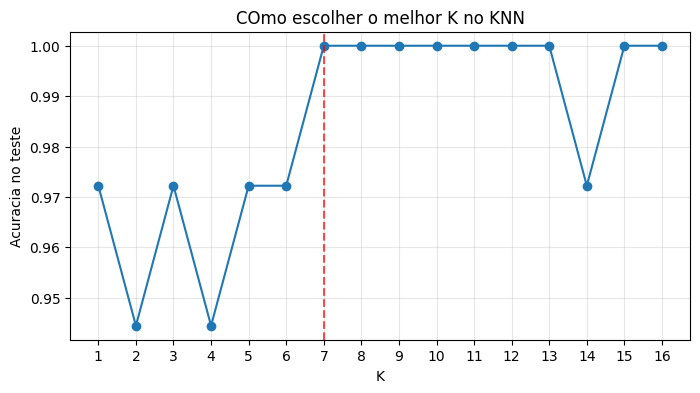

Melhor K sugerido pelo gráfico: 7


In [9]:
import matplotlib.pyplot as plt

# 178 amostras, 13 features, 3 classes
wine = load_wine()

# separar as featres e a qtd pra treino
df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
df_wine["classe"] = wine.target

X_wine = df_wine[wine.feature_names]
y_wine = df_wine["classe"]

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)

# normalização
scaler_wine = StandardScaler()
X_train_w_s = scaler_wine.fit_transform(X_train_w) # aprende os dados e transforma os dados para utilizar depois 
X_test_w_s = scaler_wine.transform(X_test_w) 

# gráfico para visualizar o melhor k 
k_values = range(1, 17)
acuracias = []

for k in k_values:
    modelo_k = KNeighborsClassifier(n_neighbors=k)
    modelo_k.fit(X_train_w_s, y_train_w)
    acuracias.append(modelo_k.score(X_test_w_s, y_test_w))

melhor_k = k_values[acuracias.index(max(acuracias))]

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), acuracias, marker='o')
plt.xticks(list(k_values))
plt.xlabel("K")
plt.xlabel("K")
plt.ylabel("Acuracia no teste")
plt.title("COmo escolher o melhor K no KNN")
plt.grid(True, alpha=0.3)
plt.axvline(melhor_k, color="red", linestyle="--", alpha=0.7)
plt.show()

print(f"Melhor K sugerido pelo gráfico: {melhor_k}")

# Recomendação por similaridade

In [12]:
wine = load_wine()

vinhos = pd.DataFrame(wine.data, columns=wine.feature_names)

vinhos["tipo"] = [wine.target_names[t] for t in wine.target]
vinhos["id_vinho"] = vinhos.index

print("Amostra do catalogo:")
print(vinhos[["id_vinho", "tipo", "alcohol", 'malic_acid', "color_intensity"]].head(8))

Amostra do catalogo:
   id_vinho     tipo  alcohol  malic_acid  color_intensity
0         0  class_0    14.23        1.71             5.64
1         1  class_0    13.20        1.78             4.38
2         2  class_0    13.16        2.36             5.68
3         3  class_0    14.37        1.95             7.80
4         4  class_0    13.24        2.59             4.32
5         5  class_0    14.20        1.76             6.75
6         6  class_0    14.39        1.87             5.25
7         7  class_0    14.06        2.15             5.05


In [ ]:
x_rec = vinhos[wine.feature_names]

# normalização 
scaler_rec = StandardScaler()
X_rec_scaled = scaler_rec.fit_transform(x_rec)

# euclidean usa pitágoras, manhattan usa a soma das diferenças absolutas
metrica_rec = "euclidean" # ou "manhattan"
modelo_rec = NearestNeighbors(n_neighbors=4, metric=metrica_rec)
modelo_rec.fit(X_rec_scaled)

id_referencia = 10
referencia = X_rec_scaled[[id_referencia]]
distancias, indices = modelo_rec.kneighbors(referencia)

print(f"Metrica usada: {metrica_rec}")
print(f"Vinho de referencia (id={id_referencia}), tipo={vinhos.iloc[id_referencia]['tipo']}") # iloc é pra pesquisar dentro do dataframe
print()

print("Vinhos mais parecidos (incluindo ele mesmo na posição 0):")
for i, idx in enumerate(indices[0]):
    tipo = vinhos.iloc[idx]["tipo"]
    dist = distancias[0][i]
    print(f" id={idx} | tipo={tipo} | distancia={dist:.3f}")

Metrica usada: manhattan
Vinho de referencia (id=10), tipo=class_0

Vinhos mais parecidos (incluindo ele mesmo na posição 0):
 id=10 | tipo=class_0 | distancia=0.000
 id=31 | tipo=class_0 | distancia=4.364
 id=51 | tipo=class_0 | distancia=5.362
 id=48 | tipo=class_0 | distancia=5.410


In [17]:
def recomendar_vinhos(id_vinho, n=3):
    referencia = X_rec_scaled[[id_vinho]]

    distancias, indices = modelo_rec.kneighbors(referencia, n_neighbors=n+1) # +1 pra incluir o próprio vinho

    tipo_ref = vinhos.iloc[id_vinho]["tipo"]
    print(f"Quem gostou do vinho id={id_vinho} (tipo={tipo_ref}) pode gostar de: ")
    for i, idx in enumerate(indices[0]):
        if idx == id_vinho:
            continue # pula o próprio vinho de ref pra não dar como recomendação o vinho que foi passado
        tipo = vinhos.iloc[idx]["tipo"]
        dist = distancias[0][i]
        print(f"- id={idx} | tipo={tipo} | distancia={dist:.3f}")

recomendar_vinhos(10)
print()
recomendar_vinhos(130)


Quem gostou do vinho id=10 (tipo=class_0) pode gostar de: 
- id=31 | tipo=class_0 | distancia=4.364
- id=51 | tipo=class_0 | distancia=5.362
- id=48 | tipo=class_0 | distancia=5.410

Quem gostou do vinho id=130 (tipo=class_2) pode gostar de: 
- id=131 | tipo=class_2 | distancia=5.607
- id=133 | tipo=class_2 | distancia=5.918
- id=163 | tipo=class_2 | distancia=7.322
